# Training Comparison: Newton's method VS. first-order methods

Compare gradient descent, Adam, Gauss–Newton, and Newton methods on a synthetic regression problem.

## 1. Setup

In [1]:
import os
import sys
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

PROJECT_DIR = "/mnt/data/nntk_refactor"  # change if you move the files
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

from config import ExperimentConfig
from data import make_problem, make_problem_NN, set_run_seed
from model import NN
from ntk import ntk_eigensystem, project_onto_ntk_modes
from plotting import (
    set_plot_style,
    plot_loss_vs_iteration,
    plot_loss_vs_time,
    plot_component_errors,
    plot_ntk_errors,
    save_training_animation
)

from training import aggregate_runs, run_one_seed, tune_learning_rate

dtype = torch.float64
torch.set_default_dtype(dtype)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

set_plot_style()
os.makedirs("Figures/NNTK", exist_ok=True)

Using device: cpu


## 2. Configuration, data, and NTK eigensystem

In [2]:
cfg = ExperimentConfig()
print(cfg.code)

run_seeds = list(range(cfg.n_runs))

set_run_seed(1)

FINAL


### 2a. Generic target function

In [3]:
problem = make_problem(cfg, device, dtype)
x = problem["x"]
y = problem["y"]
basis = problem["basis"]
component_names = problem["component_names"]
target_component_coef = problem["target_component_coef"]

In [4]:
base_model = NN(
    input_dim=cfg.input_dim,
    hidden_dim=cfg.hidden_dim,
    output_dim=cfg.output_dim,
    beta=cfg.beta,
).to(device)

### 2b. Student-teacher model

In [5]:
# problem = make_problem_NN(cfg, device, dtype)

# x = problem["x"]
# y = problem["y"]
# basis = problem["basis"]
# target_component_coef = problem["target_component_coef"]
# teacher_model = problem["teacher_model"]

In [6]:
# base_model = NN(
#     input_dim=cfg.input_dim,
#     hidden_dim=cfg.hidden_dim,
#     output_dim=cfg.output_dim,
#     beta=cfg.beta,
# ).to(device)

# base_model.fc1.load_state_dict(teacher_model.fc1.state_dict())

### Computation of NTK eigenvalues

In [7]:
ntk_evals, ntk_evecs = ntk_eigensystem(base_model, x)
target_ntk_coef = project_onto_ntk_modes(y, ntk_evecs).detach().cpu().numpy()

print("Top NTK eigenvalues:")
print(ntk_evals[:10].detach().cpu().numpy())

Top NTK eigenvalues:
[5.57472728e+01 3.95466012e+00 1.13849907e-01 1.04990112e-02
 7.45913832e-04 8.66544920e-05 6.72359256e-06 8.96200339e-07
 1.01031506e-07 6.05244612e-09]


## 3. Learning-rate selection

Set `RUN_LR_TUNING` to `True` to run pilot sweeps; otherwise use the manual learning rates.

In [8]:
RUN_LR_TUNING = False

if RUN_LR_TUNING:
    gd_grid = np.logspace(-4, 1, 16)
    adam_grid = np.logspace(-4, 1, 16)
    cfg.gd_lr, gd_sweep_losses = tune_learning_rate(
        "GD", gd_grid, cfg, x, y, basis, target_component_coef,
        ntk_evecs, target_ntk_coef, seed=0, pilot_epochs=5_000,
    )
    cfg.adam_lr, adam_sweep_losses = tune_learning_rate(
        "Adam", adam_grid, cfg, x, y, basis, target_component_coef,
        ntk_evecs, target_ntk_coef, seed=0, pilot_epochs=1_000,
    )
else:
    cfg.gd_lr = 4.0
    cfg.adam_lr = 0.01

print(f"GD learning rate:   {cfg.gd_lr:.3e}")
print(f"Adam learning rate: {cfg.adam_lr:.3e}")


GD learning rate:   4.000e+00
Adam learning rate: 1.000e-02


## 4. Single-seed training dynamics

In [9]:
method_order = ["GD", "Adam", "GN", "Newton"]

method_labels = {
    "GD": "gradient descent",
    "Adam": "Adam",
    "GN": "regularized Gauss-Newton method",
    "Newton": "regularized Newton method",
}
method_colors = {
    "GD": "crimson",
    "Adam": "darkorange",
    "GN": "C2",
    "Newton": "C0",
}

In [10]:
single_seed_history = run_one_seed(
    cfg,
    x,
    y,
    basis,
    target_component_coef,
    ntk_evecs,
    target_ntk_coef,
    seed=0,
)

print(single_seed_history.keys())
print("GD final loss:", single_seed_history["GD"]["loss"][-1])
print("Adam final loss:", single_seed_history["Adam"]["loss"][-1])
print("GN final loss:", single_seed_history["GN"]["loss"][-1])
print("Newton final loss:", single_seed_history["Newton"]["loss"][-1])

for method in ["GD", "Adam", "GN", "Newton"]:
    h = single_seed_history[method]
    print(
        method,
        f"training time = {h['time'][-1]:.3f}s,",
        f"stored snapshots = {len(h['iterates'])},",
        f"snapshot-time range = {h['iterate_times'][0]:.3f}s"
        f"–{h['iterate_times'][-1]:.3f}s",
    )

dict_keys(['GD', 'Adam', 'Newton', 'GN'])
GD final loss: 0.03824232316057988
Adam final loss: 5.736341397260238e-05
GN final loss: 6.321009235875916e-05
Newton final loss: 3.6802890852918226e-05
GD training time = 28.717s, stored snapshots = 73, snapshot-time range = 0.000s–28.717s
Adam training time = 30.890s, stored snapshots = 79, snapshot-time range = 0.000s–30.890s
GN training time = 23.418s, stored snapshots = 60, snapshot-time range = 0.000s–23.418s
Newton training time = 32.127s, stored snapshots = 81, snapshot-time range = 0.000s–32.127s


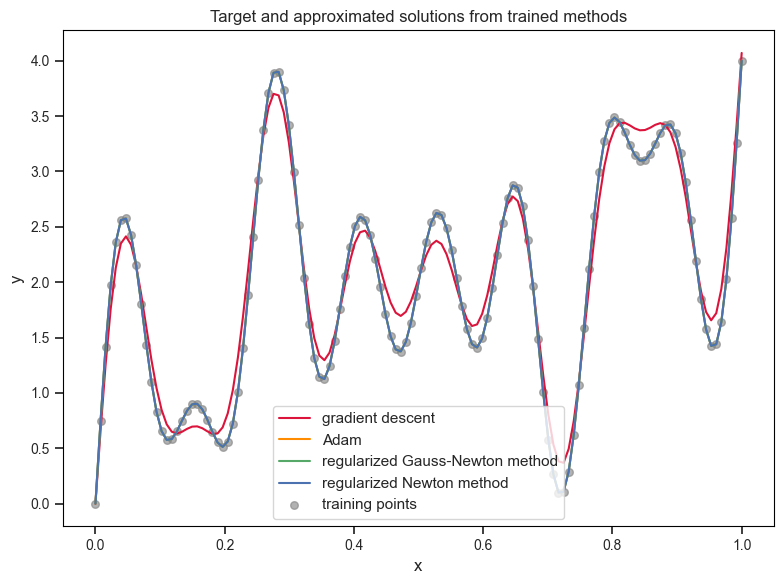

In [11]:
x_np = x.cpu().numpy().flatten()
basis_np = basis.cpu().numpy()
y_target = basis_np @ target_component_coef

methods = ["GD", "Adam", "GN", "Newton"]

plt.figure(figsize=(8, 6))
#plt.plot(x_np, y_target, label="target", color="black", linewidth=2)

for method in methods:
    coef = single_seed_history[method]["component_coef"][-1]
    y_pred = basis_np @ coef
    plt.plot(
        x_np,
        y_pred.flatten(),
        label=method_labels[method],
        color=method_colors[method],
        linewidth=1.5,
    )

plt.scatter(x_np, y.cpu().numpy().flatten(), label="training points", color="gray", s=30, alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Target and approximated solutions from trained methods")
plt.legend()
plt.tight_layout()
plt.show()

### Optional: training animations

In [12]:
methods = ["GD", "Adam", "GN", "Newton"]

for method in methods:
    output_path = save_training_animation(
        single_seed_history=single_seed_history,
        cfg=cfg,
        method=method,
        method_labels=method_labels,
        method_colors=method_colors,
        x_train=x,
        y_train=y,
        x_plot=x,
        y_target=y,
        device=device,
        dtype=dtype,
    )
    print(f"Saved animation to {output_path}")

Saved animation to Figures/NNTK/Comparison_GD_Newton_training_evolution_GD.gif
Saved animation to Figures/NNTK/Comparison_GD_Newton_training_evolution_Adam.gif
Saved animation to Figures/NNTK/Comparison_GD_Newton_training_evolution_GN.gif
Saved animation to Figures/NNTK/Comparison_GD_Newton_training_evolution_Newton.gif


## 5. Multi-seed experiment

In [13]:
run_histories = [
    run_one_seed(
        cfg,
        x,
        y,
        basis,
        target_component_coef,
        ntk_evecs,
        target_ntk_coef,
        seed,
    )
    for seed in run_seeds
]

histories = aggregate_runs(run_histories)

## 6. Aggregate comparison plots

In [14]:
method_order = ["GD", "Adam", "GN", "Newton"]

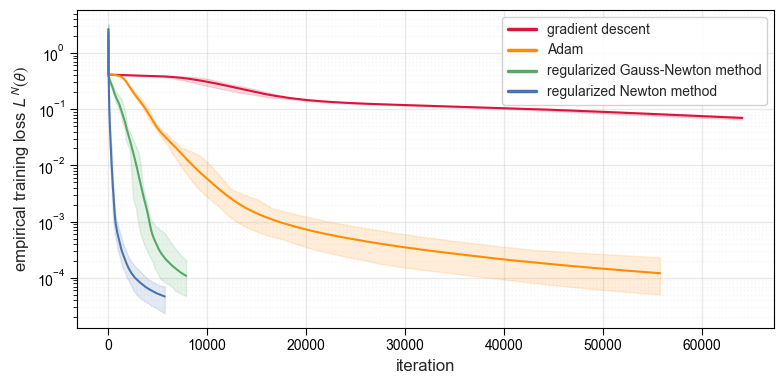

In [15]:
production = 1
time_horizon = 20.0

plot_loss_vs_iteration(
    run_histories, method_order, method_colors, method_labels,
    save_path="Figures/NNTK/Comparison_GD_Newton_Iterations.pdf",
    production=production, time_horizon=time_horizon,
)
plt.show()


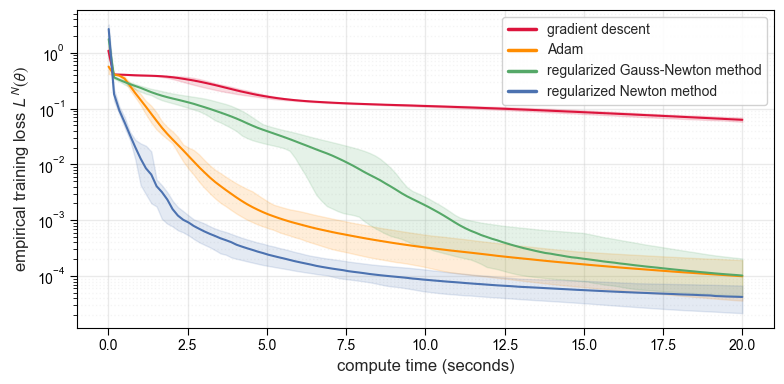

In [16]:
plot_loss_vs_time(
    run_histories,
    method_order,
    method_colors,
    method_labels,
    save_path="Figures/NNTK/Comparison_GD_Newton_ComputeTime.pdf",
    production=production,
    time_horizon=time_horizon,
)
plt.show()

In [17]:
method_order = ["GD", "Newton"]

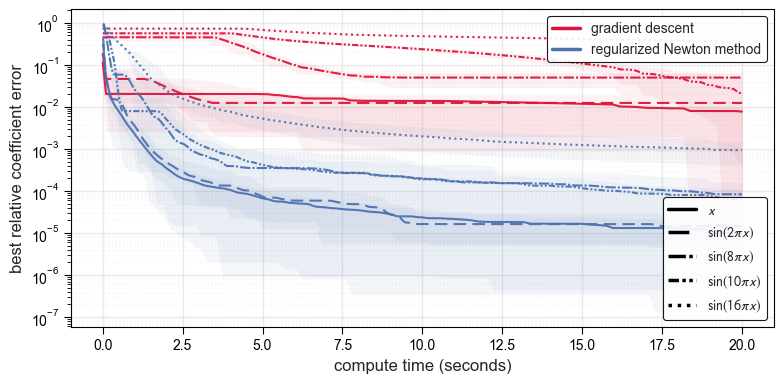

In [18]:
plot_component_errors(
    histories=histories,
    cfg=cfg,
    method_order=method_order,
    method_labels=method_labels,
    method_colors=method_colors,
    save_path="Figures/NNTK/Comparison_GD_Newton_FrequenciesLearned.pdf",
    smooth_time_fraction=0.01,
    error_type="relative",
    production=True,
    time_horizon=time_horizon,
)
plt.show()

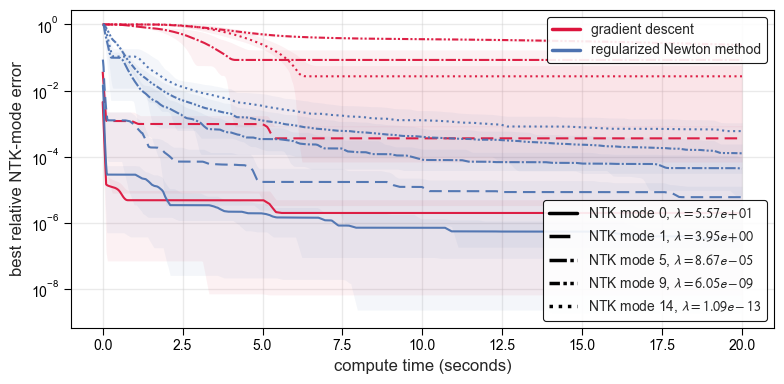

In [19]:
plot_ntk_errors(
    histories,
    ntk_evals,
    target_ntk_coef,
    method_order,
    method_labels,
    method_colors,
    production=1,
    time_horizon=time_horizon,
    save_path="Figures/NNTK/Comparison_GD_Newton_NTKModesLearned.pdf",
    smooth_time_fraction=0.01,
    error_type="relative"
)
plt.show()